# THPTQG Trends — Google Colab

Phân tích điểm THPT quốc gia **2021–2025** và dự báo xu hướng.

**Chạy lần lượt từ trên xuống.** File CSV ~805MB không có trên GitHub — dùng **Google Drive** hoặc upload `cleaned_data.csv`.


In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn statsmodels pyarrow


In [2]:
import os, sys
from pathlib import Path

ROOT = Path("/content/thptqg-trends")
if not ROOT.exists():
    !git clone https://github.com/2274802010922/thptqg-trends.git /content/thptqg-trends
else:
    !cd /content/thptqg-trends && git pull

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.display import setup_display
setup_display()
print("Project:", ROOT)


Cloning into '/content/thptqg-trends'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 81 (delta 16), reused 75 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (81/81), 602.78 KiB | 5.38 MiB/s, done.
Resolving deltas: 100% (16/16), done.
Project: /content/thptqg-trends


## Nguồn dữ liệu (chọn **một** cách)

### Cách A: Google Drive (khuyên dùng)


In [3]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")
CSV_PATH = "/content/drive/MyDrive/do an thuc tap/cleaned_data.csv"
assert Path(CSV_PATH).exists(), f"Không tìm thấy: {CSV_PATH}"
print("CSV:", CSV_PATH)


Mounted at /content/drive
CSV: /content/drive/MyDrive/do an thuc tap/cleaned_data.csv


In [4]:
from src.config import configure

YEAR_MIN, YEAR_MAX = 2021, 2025
configure(csv_path=CSV_PATH, year_min=YEAR_MIN, year_max=YEAR_MAX)
print(f"Phạm vi: {YEAR_MIN}-{YEAR_MAX}")


Phạm vi: 2021-2025


In [5]:
import time
from IPython.display import display
from src.load_data import count_rows
from src.aggregates import save_aggregates
from src.forecast import run_forecast_pipeline
from src.plots import generate_all_figures
from src.report import generate_report
from src.display import pretty_counts, pretty_forecast

t0 = time.time()
print("1/5 Kiểm tra dữ liệu")
display(pretty_counts(count_rows()))
print("2/5 Aggregate")
save_aggregates()
print("3/5 Dự báo")
display(pretty_forecast(run_forecast_pipeline()))
print("4/5 Biểu đồ")
for f in generate_all_figures():
    print(" ", f.name)
print("5/5 Báo cáo:", generate_report())
print(f"HOÀN TẤT {(time.time()-t0)/60:.1f} phút")


1/5 Kiểm tra dữ liệu


,Năm,Số thí sinh,Số thí sinh (raw)
0,2021,987.704,987704
1,2022,995.441,995441
2,2023,1.022.060,1022060
3,2024,1.061.605,1061605
4,2025,1.131.136,1131136


2/5 Aggregate
3/5 Dự báo


,Môn,Năm dự báo,Điểm TB dự kiến,MAE backtest,Thực tế năm cuối
0,Toán,2026,"4,922","0,7937","5,564"
1,Ngữ văn,2026,"7,485","0,3361","7,833"
2,Ngoại ngữ,2026,"5,373","0,5980","6,132"
3,Vật lý,2026,"6,956","0,7199","7,400"
4,Hóa học,2026,"6,165","0,0408","6,692"
5,Sinh học,2026,"6,411","0,1687","6,843"


4/5 Biểu đồ


/content/thptqg-trends/src/plots.py:47: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) Noto Sans.
  fig.tight_layout()
/content/thptqg-trends/src/plots.py:50: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) Noto Sans.
  fig.savefig(out_path, dpi=150)


  candidates_by_year.png
  pct_ge_8_by_year.png
  mean_by_year_Toan.png
  mean_by_year_NguVan.png
  mean_by_year_NgoaiNgu.png
  mean_by_year_VatLy.png
  mean_by_year_HoaHoc.png
  mean_by_year_SinhHoc.png
  heatmap_Toan_2025.png
  forecast_Toan.png
  forecast_NguVan.png
  forecast_NgoaiNgu.png
5/5 Báo cáo: /content/thptqg-trends/reports/BAO_CAO.md
HOÀN TẤT 1.5 phút


In [6]:
from IPython.display import Markdown, display
from pathlib import Path
display(Markdown(Path("README.md").read_text(encoding="utf-8")))


# Báo cáo phân tích điểm THPT quốc gia

**Ngày tạo:** 29/05/2026 11:49
**Dữ liệu:** `/content/drive/MyDrive/do an thuc tap/cleaned_data.csv`
**Phạm vi:** 2021 – 2025

## 1. Tổng quan

- Tổng số thí sinh (5 năm): **5.197.946**
- Năm **2021**: 987.704 thí sinh
- Năm **2022**: 995.441 thí sinh
- Năm **2023**: 1.022.060 thí sinh
- Năm **2024**: 1.061.605 thí sinh
- Năm **2025**: 1.131.136 thí sinh

## 2. Xu hướng điểm trung bình

| Môn | TB đầu kỳ | TB cuối kỳ | Thay đổi | Tỷ lệ ≥ 8 (cuối kỳ) |
|-----|-----------|------------|----------|---------------------|
| Công nghệ công nghiệp | 6,26 | 6,28 | +0.23% | 19.4% |
| Công nghệ nông nghiệp | 7,46 | 7,86 | +5.36% | 52.5% |
| GDCD | 8,23 | 8,02 | -2.61% | 60.9% |
| Hóa học | 6,36 | 5,51 | -13.27% | 11.2% |
| Kinh tế & Pháp luật | 7,98 | 7,51 | -5.88% | 42.8% |
| Lịch sử | 4,92 | 6,46 | +31.26% | 20.6% |
| Ngoại ngữ | 6,69 | 4,92 | -26.44% | 2.7% |
| Ngữ văn | 6,73 | 6,95 | +3.28% | 22.5% |
| Sinh học | 5,24 | 5,45 | +4.04% | 5.2% |
| Tin học | 7,51 | 6,34 | -15.61% | 15.6% |
| Toán | 7,02 | 4,18 | -40.46% | 1.7% |
| Vật lý | 6,57 | 6,49 | -1.27% | 19.3% |
| Địa lý | 6,83 | 6,56 | -3.87% | 24.2% |

## 3. Top 10 tỉnh — Toán 2025

1. **Ninh Bình** — 5,64 điểm (23.209 thí sinh)
2. **Hà Nội** — 5,56 điểm (62.373 thí sinh)
3. **Phú Thọ** — 5,45 điểm (16.201 thí sinh)
4. **Lâm Đồng** — 5,40 điểm (16.713 thí sinh)
5. **Nghệ An** — 5,26 điểm (7.686 thí sinh)
6. **Hà Giang** — 5,25 điểm (96.488 thí sinh)
7. **Cao Bằng** — 5,20 điểm (28.752 thí sinh)
8. **Hải Dương** — 5,19 điểm (19.308 thí sinh)
9. **Bắc Kạn** — 5,17 điểm (13.964 thí sinh)
10. **Thanh Hóa** — 5,17 điểm (23.789 thí sinh)

## 4. Bottom 10 tỉnh — Toán 2025

1. **Tuyên Quang** — 3,45 điểm (7.047 thí sinh)
2. **Quảng Ninh** — 3,63 điểm (12.380 thí sinh)
3. **Lào Cai** — 3,71 điểm (4.826 thí sinh)
4. **Hòa Bình** — 3,78 điểm (3.065 thí sinh)
5. **Bạc Liêu** — 3,81 điểm (6.843 thí sinh)
6. **Hà Nam** — 3,91 điểm (10.488 thí sinh)
7. **Yên Bái** — 3,94 điểm (9.517 thí sinh)
8. **Lạng Sơn** — 4,00 điểm (9.048 thí sinh)
9. **Kiên Giang** — 4,03 điểm (10.030 thí sinh)
10. **Điện Biên** — 4,07 điểm (4.178 thí sinh)

## 5. Dự báo năm tiếp theo

| Môn | Năm | Điểm TB dự kiến | Sai số backtest (MAE) |
|-----|-----|-----------------|------------------------|
| Toán | 2026 | 4,922 | 0,7937 |
| Ngữ văn | 2026 | 7,485 | 0,3361 |
| Ngoại ngữ | 2026 | 5,373 | 0,5980 |
| Vật lý | 2026 | 6,956 | 0,7199 |
| Hóa học | 2026 | 6,165 | 0,0408 |
| Sinh học | 2026 | 6,411 | 0,1687 |

## 6. Hình ảnh

Xem thư mục `outputs/figures/`.

## 7. Giới hạn

- Giả định cơ chế thi ổn định so với các năm trước.
- Điểm 0,0 được coi là không thi môn đó.
- Dự báo trên chỉ số tổng hợp, không phải từng cá nhân.

---
*Chạy lại: `python scripts/run_all.py` hoặc notebook Colab.*

candidates_by_year.png


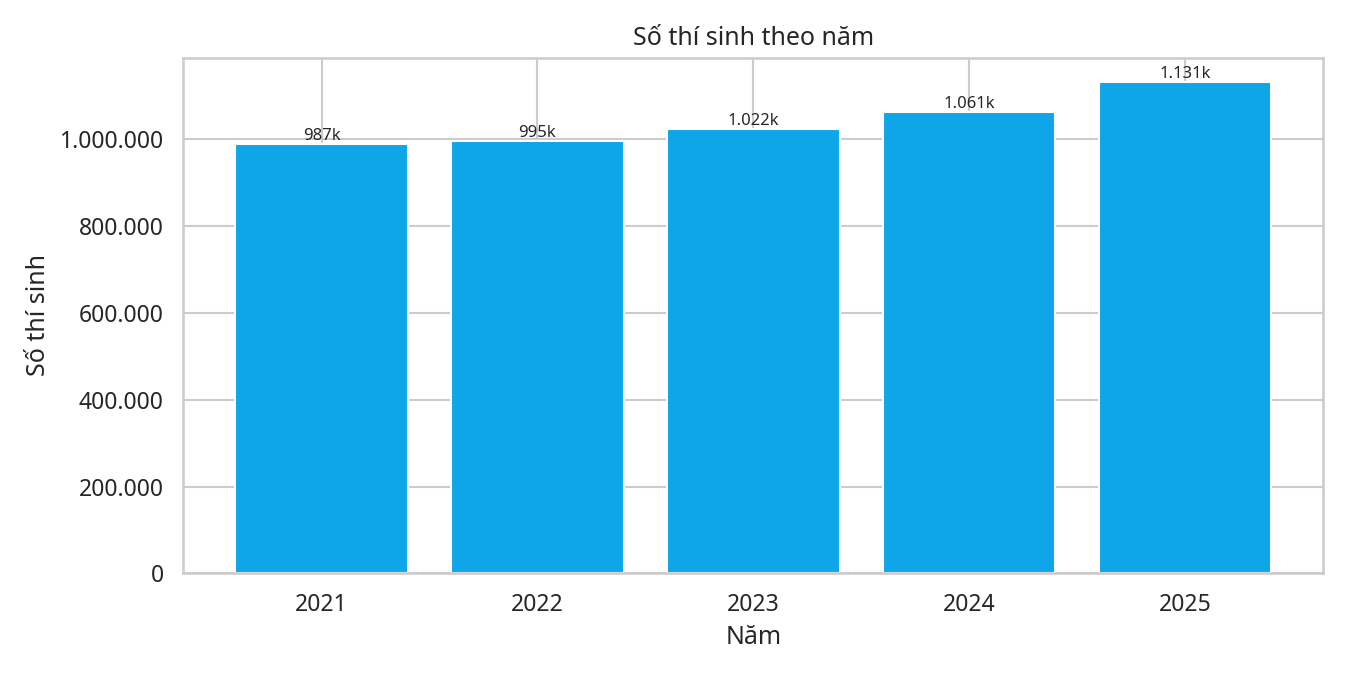

forecast_NgoaiNgu.png


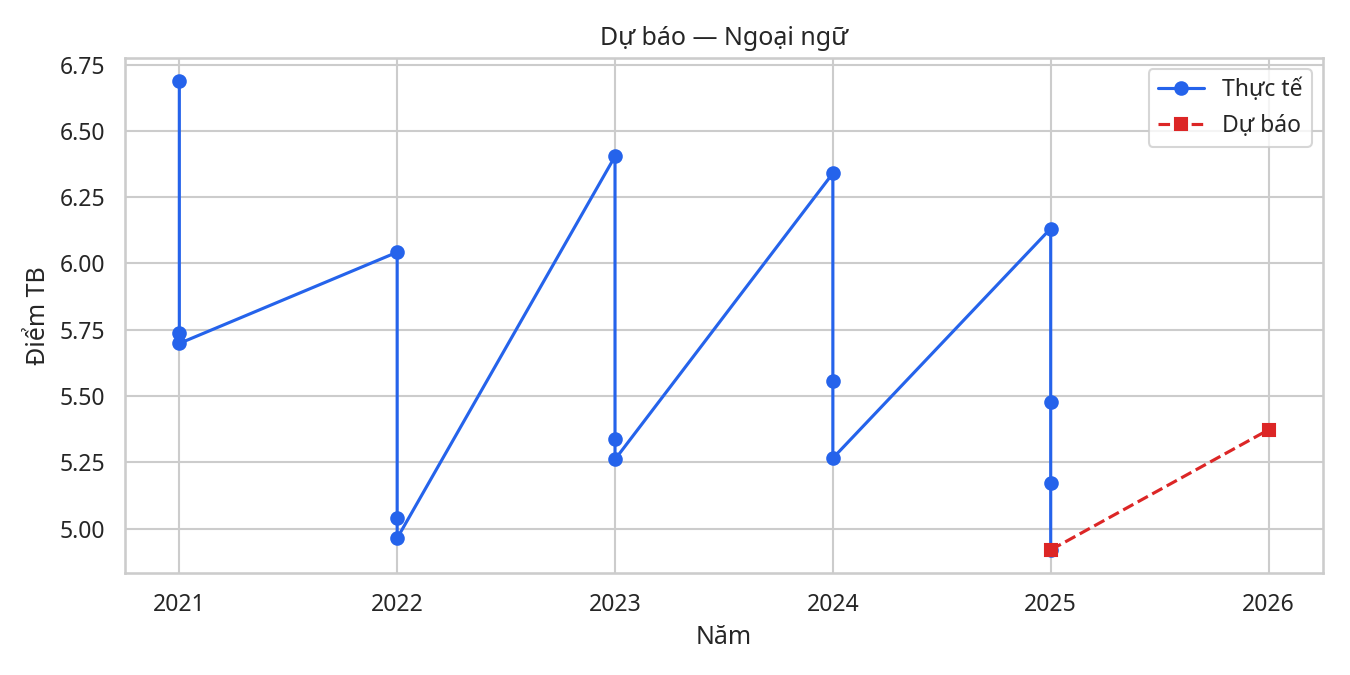

forecast_NguVan.png


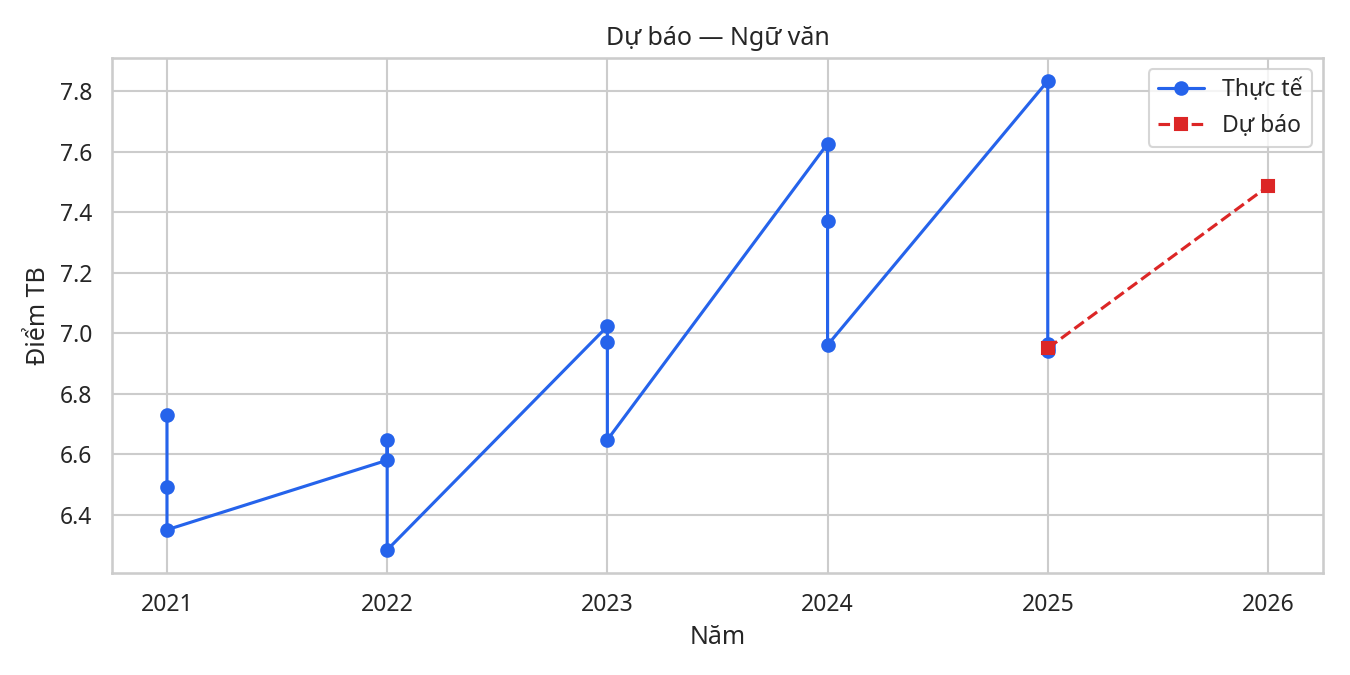

forecast_Toan.png


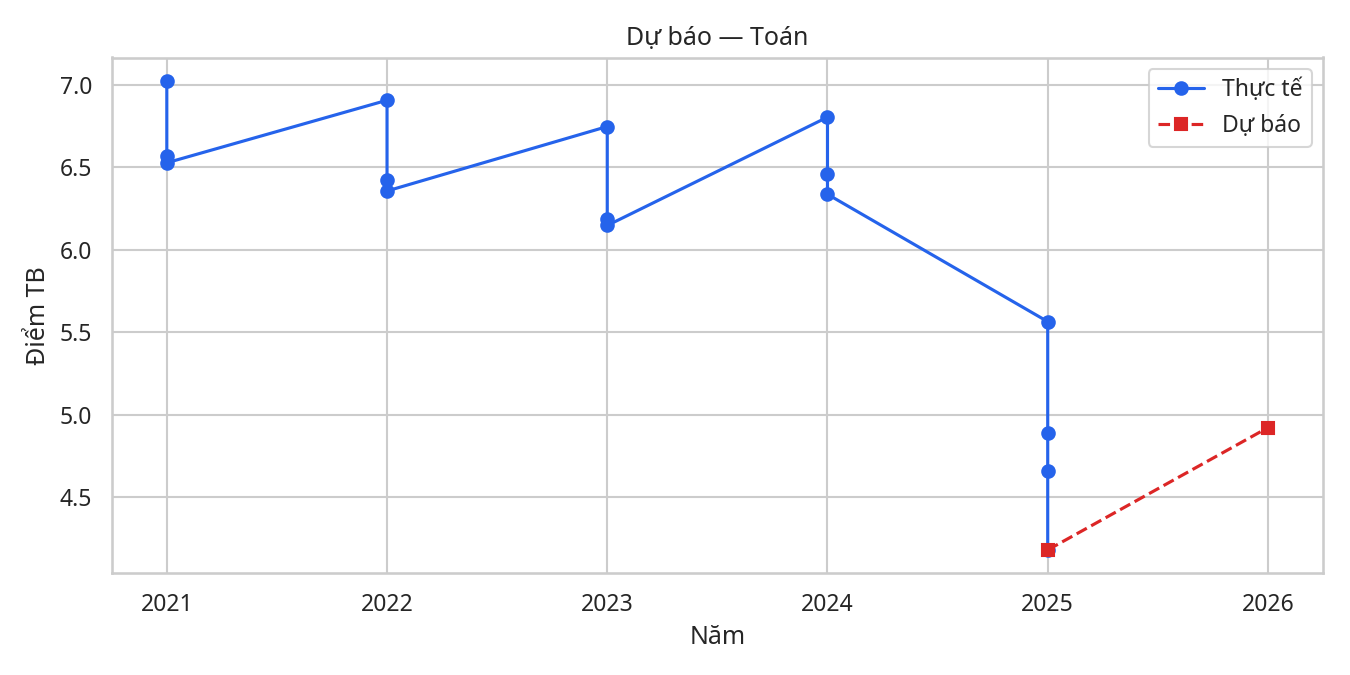

heatmap_Toan_2025.png


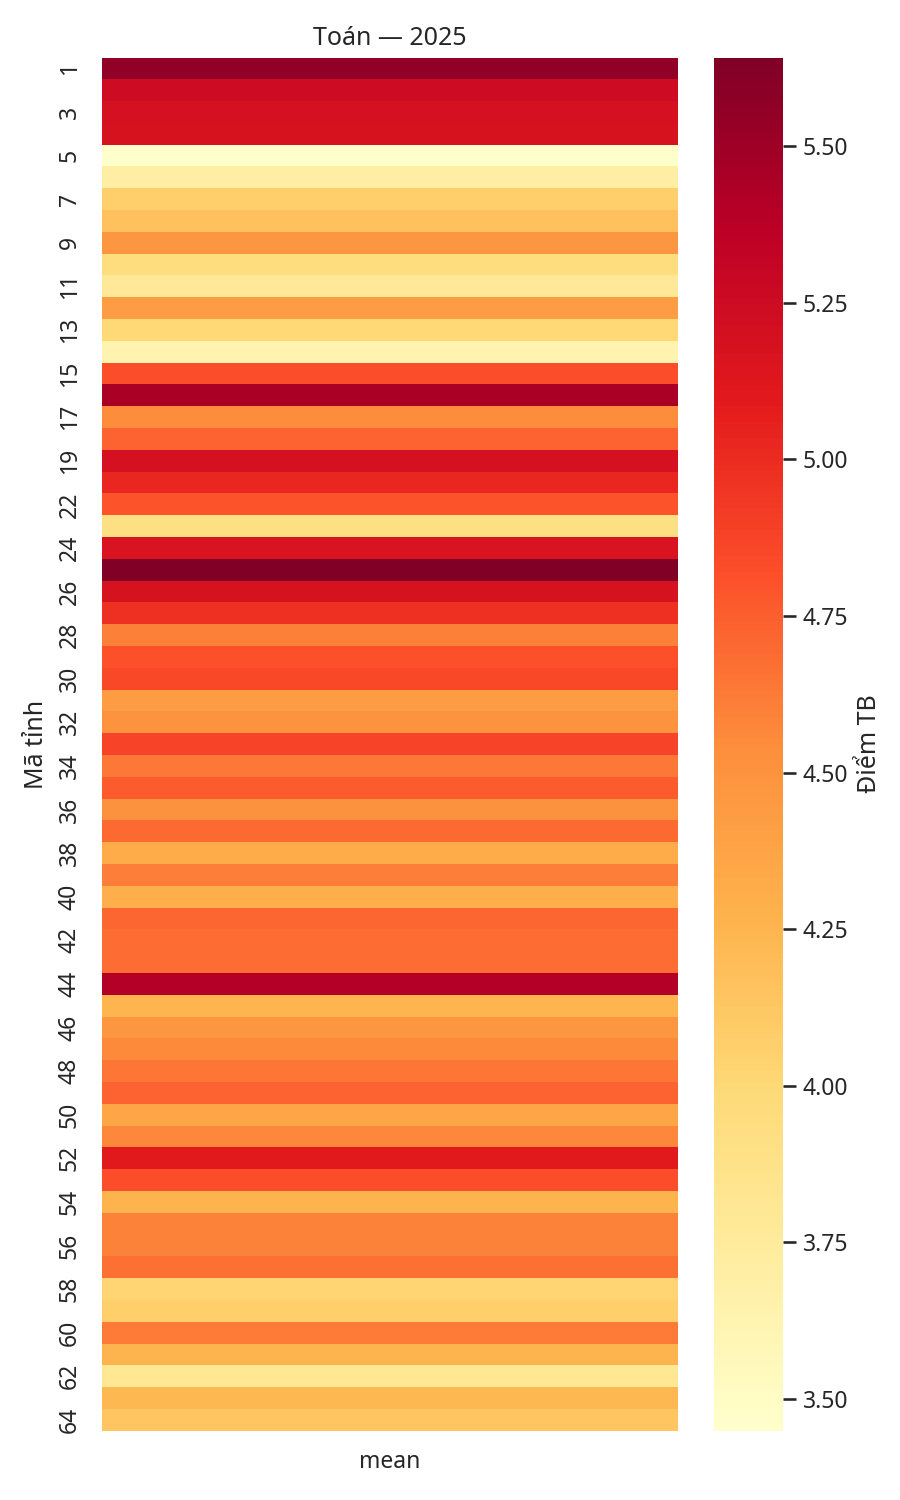

mean_by_year_HoaHoc.png


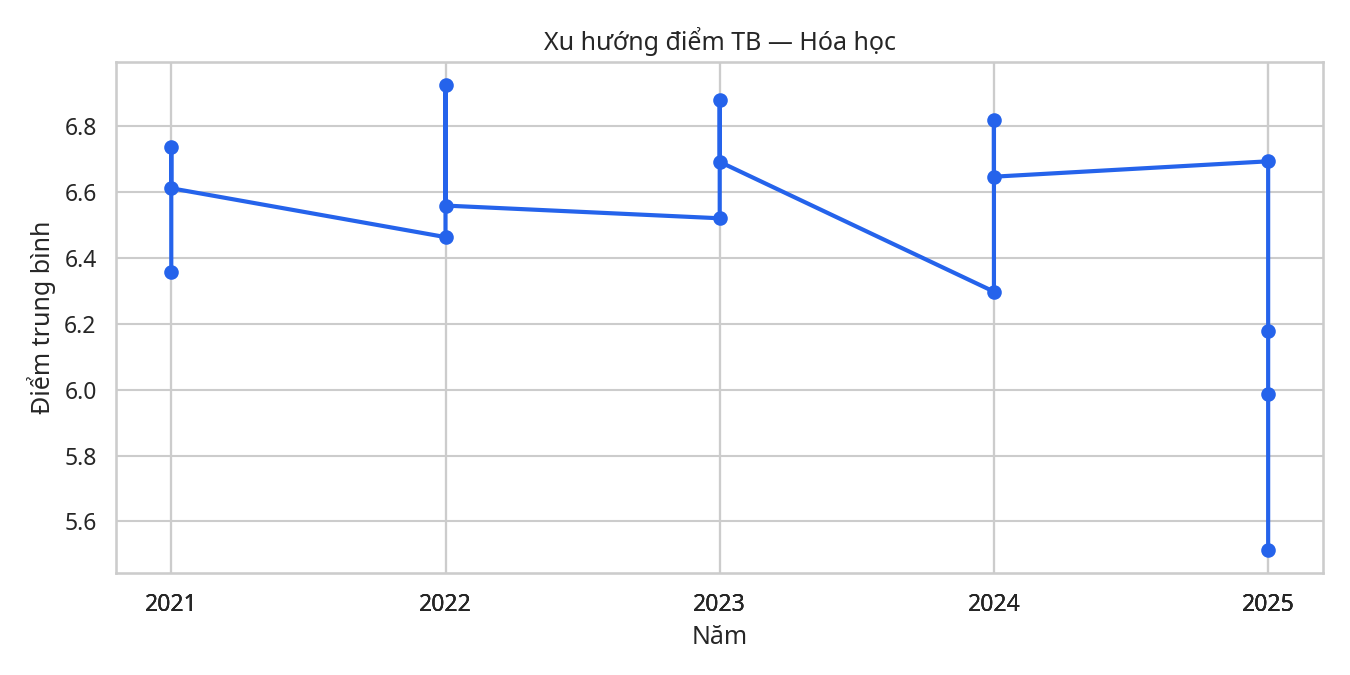

mean_by_year_NgoaiNgu.png


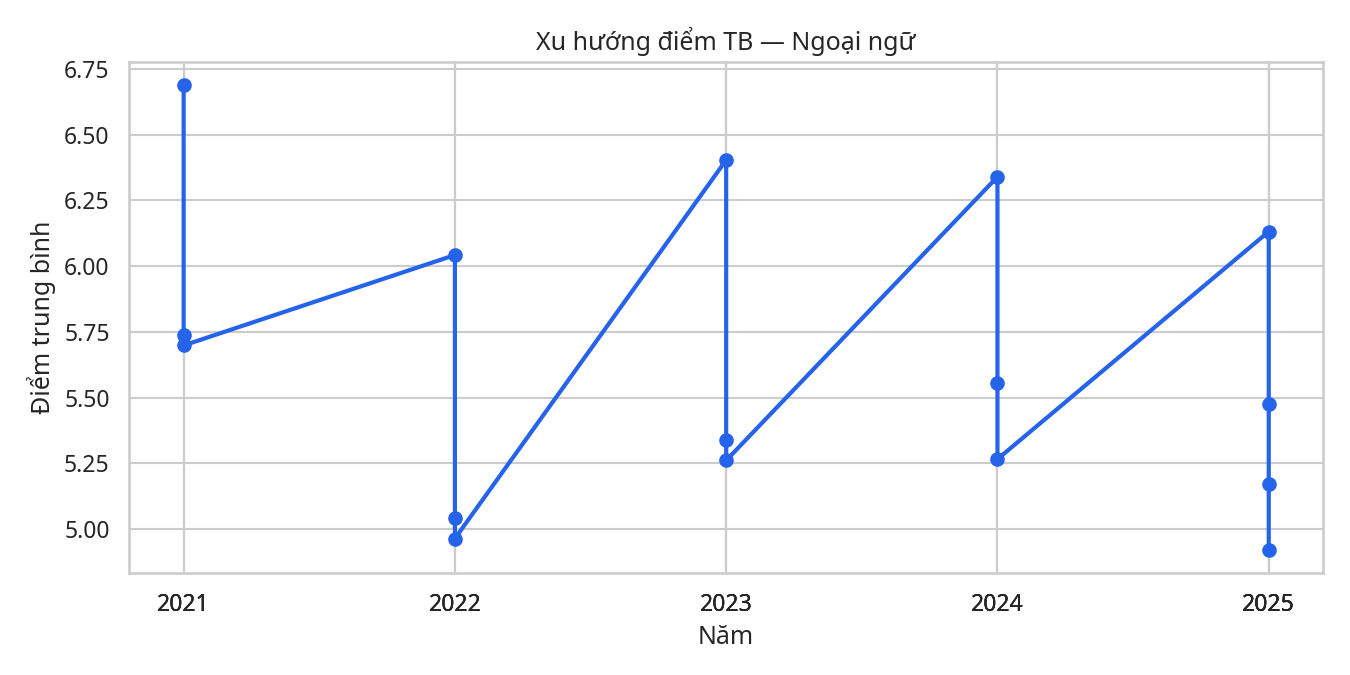

mean_by_year_NguVan.png


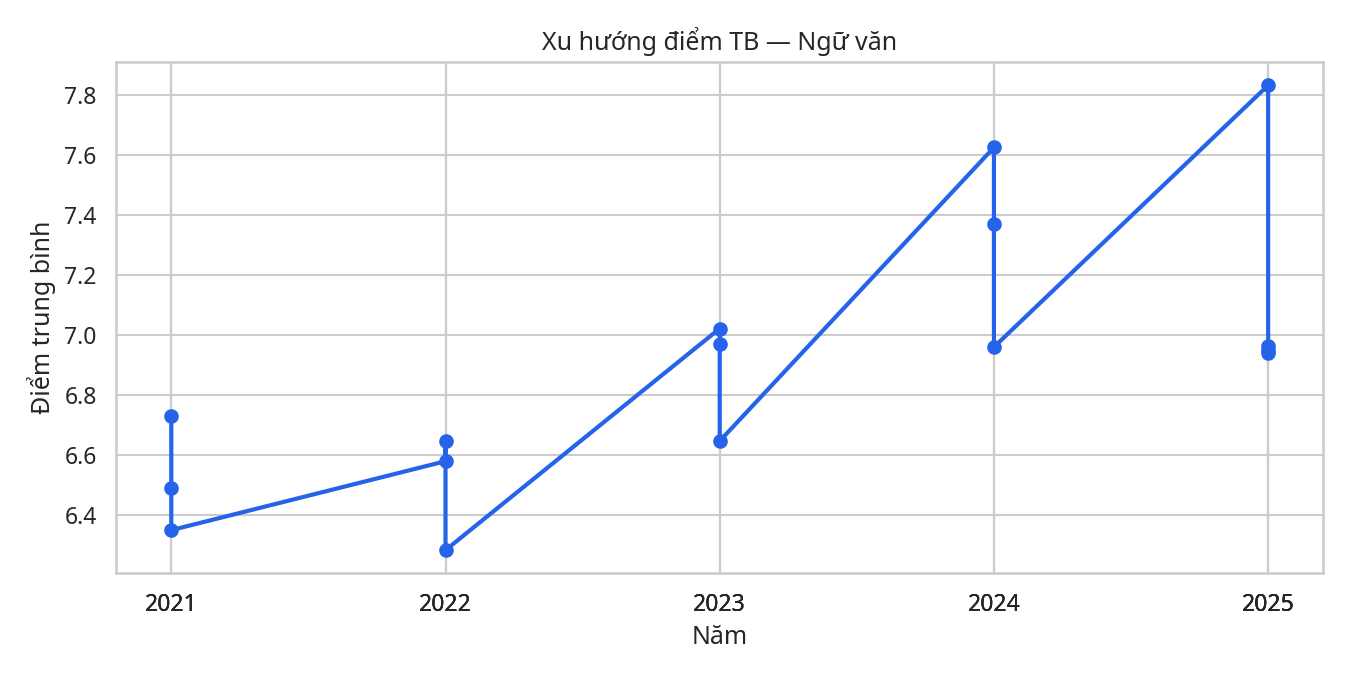

mean_by_year_SinhHoc.png


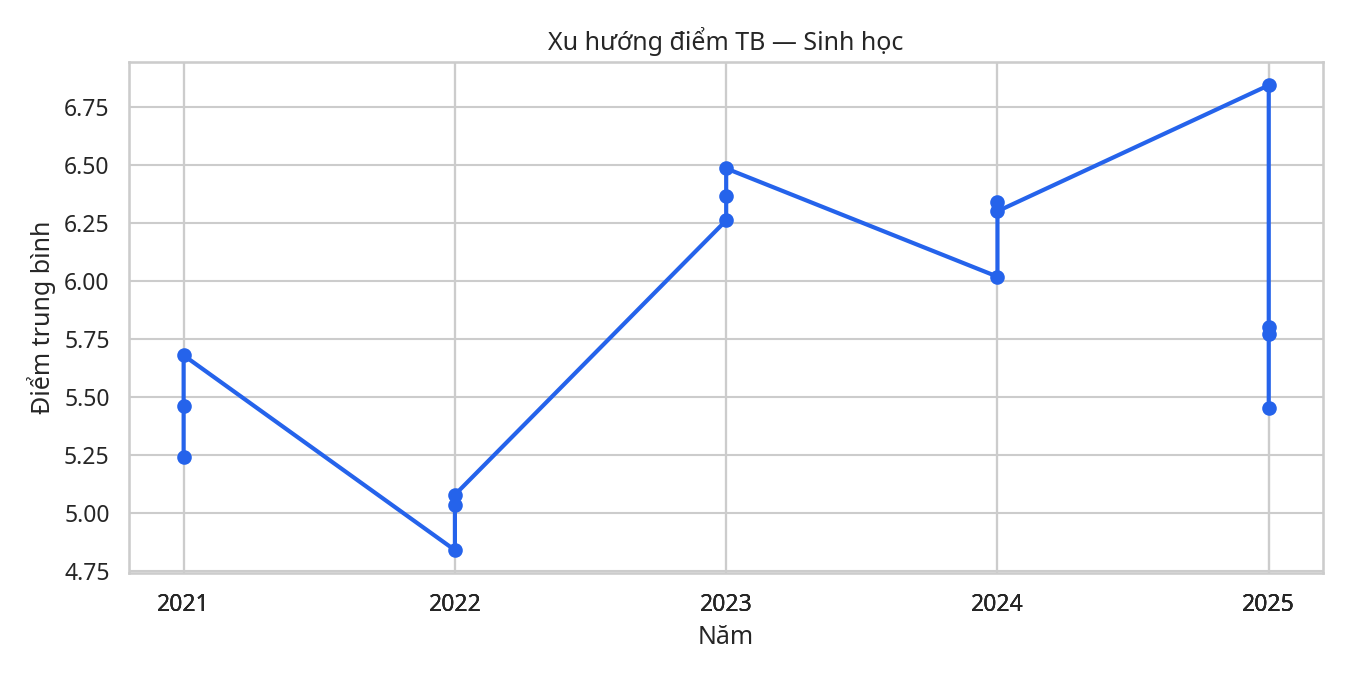

mean_by_year_Toan.png


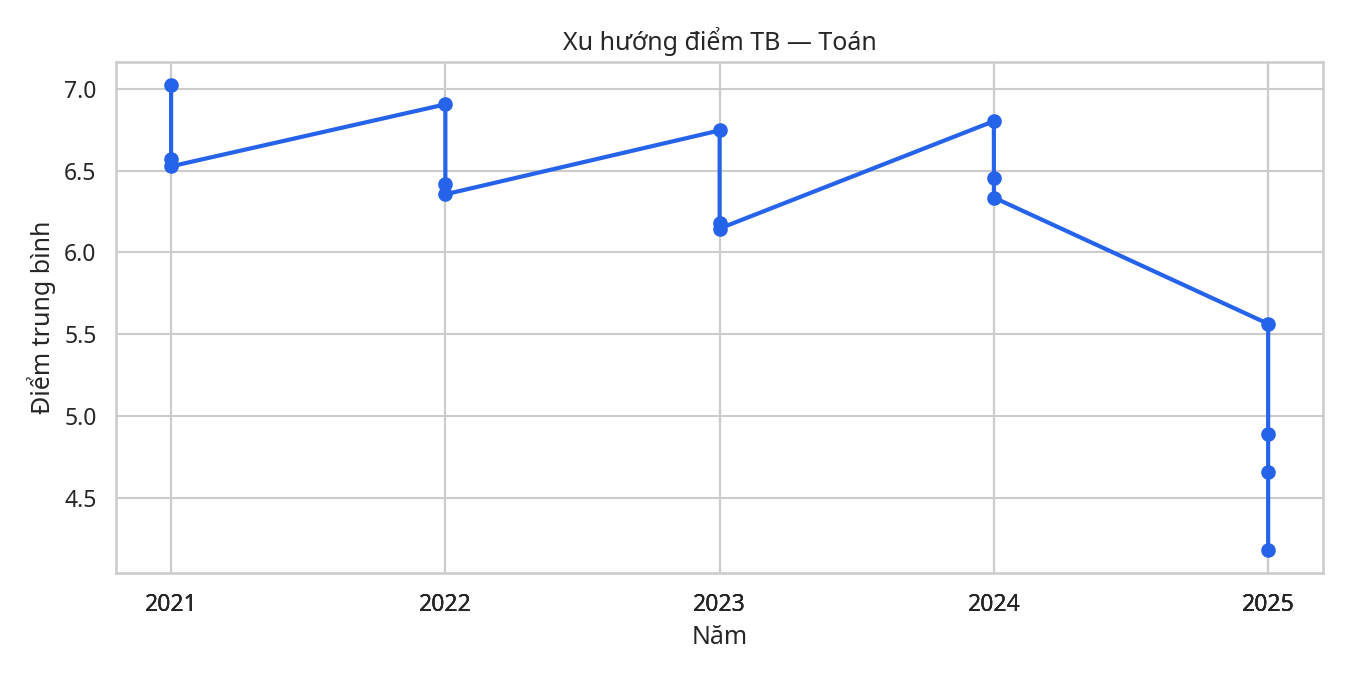

mean_by_year_VatLy.png


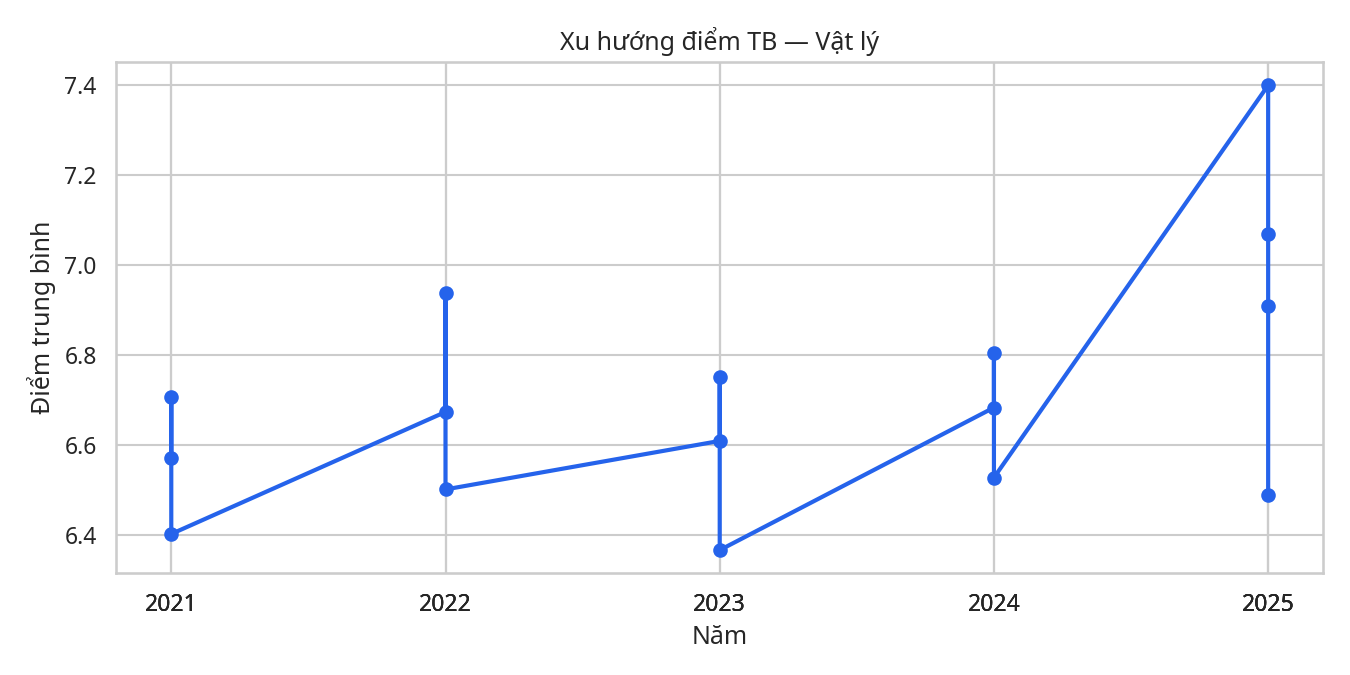

pct_ge_8_by_year.png


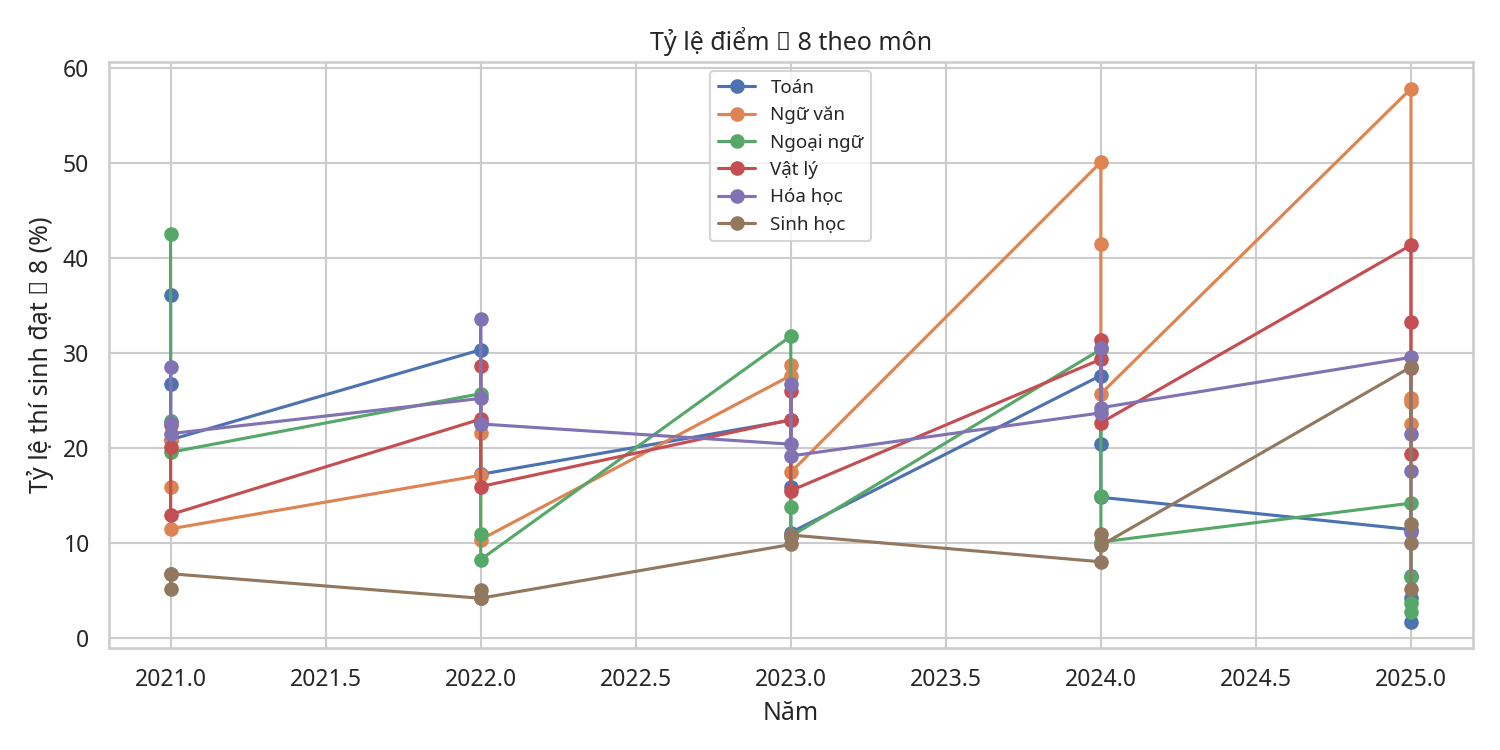

In [7]:
%matplotlib inline
from IPython.display import Image, display
from pathlib import Path
for p in sorted(Path("outputs/figures").glob("*.png")):
    print(p.name)
    display(Image(filename=str(p)))


In [8]:
import zipfile
from pathlib import Path
from google.colab import files

zip_path = Path('/content/thptqg_full.zip')
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    for f in Path('outputs').rglob('*'):
        if f.is_file():
            z.write(f, f.as_posix())
    z.write('README.md', 'README.md')
files.download(str(zip_path))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>